# 10. 모형 진단 및 검증

이 노트북은 10주차 보고서의 “진단 및 검증” 섹션에 사용할 모형 진단 결과를 산출한다. 주모형은 OLS HC3이며, H1 Baseline, H2 Headline/Model D replication, H3, Integrated Model을 중심으로 이분산, 다중공선성, 상호작용항 공선성, 잔차 분포를 확인한다.

## 1. 설정 및 라이브러리

In [ ]:
from pathlib import Path
import os
import sys
import warnings

os.environ.setdefault("MPLCONFIGDIR", str(Path("/private/tmp/matplotlib-cache").resolve()))
if "ipykernel" not in sys.modules:
    os.environ.setdefault("MPLBACKEND", "Agg")

import numpy as np
import pandas as pd
import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.api as sm
from patsy import dmatrices
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from statsmodels.stats.outliers_influence import variance_inflation_factor

try:
    from IPython.display import display, Markdown
except ImportError:
    class Markdown(str):
        pass
    def display(obj):
        print(obj)

SAVE_OUTPUTS = False

BASE_DIR = Path.cwd().resolve()
if BASE_DIR.name == "code":
    BASE_DIR = BASE_DIR.parent

DATA_CANDIDATES = [
    BASE_DIR / "working" / "analysis" / "nia_2024_analysis_total.csv",
    BASE_DIR / "working" / "featured" / "nia_2024_featured.csv",
    BASE_DIR / "working" / "cleaned" / "nia_2024_cleaned.csv",
]

OUTPUT_DIR = BASE_DIR / Path("outputs/10_model_diagnostics")
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"

if SAVE_OUTPUTS:
    TABLE_DIR.mkdir(parents=True, exist_ok=True)
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

print("BASE_DIR:", BASE_DIR)
print("SAVE_OUTPUTS:", SAVE_OUTPUTS)
print("OUTPUT_DIR:", OUTPUT_DIR)

BASE_DIR: /Users/yenarue/Downloads/ITM.89912(A)/연구 데이터
SAVE_OUTPUTS: True
OUTPUT_DIR: /Users/yenarue/Downloads/ITM.89912(A)/연구 데이터/outputs/10_model_diagnostics


## 2. 데이터 로드 및 변수 확인

In [2]:
existing_candidates = [path for path in DATA_CANDIDATES if path.exists()]
if not existing_candidates:
    candidate_text = "\n".join(f"- {path}" for path in DATA_CANDIDATES)
    raise FileNotFoundError("분석 데이터 파일을 찾지 못했습니다. 아래 후보 경로를 확인하세요:\n" + candidate_text)

DATA_PATH = existing_candidates[0]
df = pd.read_csv(DATA_PATH, low_memory=False)

print("사용 데이터 파일:", DATA_PATH.relative_to(BASE_DIR))
print("데이터 shape:", df.shape)

사용 데이터 파일: working/analysis/nia_2024_analysis_total.csv
데이터 shape: (12203, 103)


In [3]:
DV = "effect_proc_improve"
AI = "ai_use_sum"
IT_ORG = "it_org_any"
DMI = "dmi"
INVEST = "it_invest_sum"
BASE_CONTROLS = ["firm_size", "industry", "region", "firm_type"]
REQUIRED_VARS = [DV, AI, IT_ORG, DMI, INVEST, "firm_size", "industry", "region", "firm_type"]

variable_check = pd.DataFrame([
    {
        "변수명": var,
        "존재 여부": "있음" if var in df.columns else "없음",
        "유효 N": int(df[var].notna().sum()) if var in df.columns else np.nan,
        "결측 N": int(df[var].isna().sum()) if var in df.columns else np.nan,
        "dtype": str(df[var].dtype) if var in df.columns else "해당 없음",
    }
    for var in REQUIRED_VARS
])
display(variable_check)

missing_required = [var for var in REQUIRED_VARS if var not in df.columns]
if missing_required:
    raise ValueError("필수 변수가 없어 진단을 중단합니다: " + ", ".join(missing_required))

analysis_df = df[REQUIRED_VARS].copy()
for col in [DV, AI, IT_ORG, DMI, INVEST, "firm_size"]:
    analysis_df[col] = pd.to_numeric(analysis_df[col], errors="coerce")

print("진단 대상 변수 준비 완료")

,변수명,존재 여부,유효 N,결측 N,dtype
0,effect_proc_improve,있음,12203,0,int64
1,ai_use_sum,있음,12203,0,int64
2,it_org_any,있음,12203,0,int64
3,dmi,있음,12203,0,int64
4,it_invest_sum,있음,12203,0,int64
5,firm_size,있음,12203,0,int64
6,industry,있음,12203,0,int64
7,region,있음,12203,0,int64
8,firm_type,있음,12203,0,int64


진단 대상 변수 준비 완료


## 3. 모형 재추정

모든 모형은 `statsmodels` formula API로 재추정하며, 표준오차는 HC3 robust standard error를 적용한다.

In [4]:
MODEL_SPECS = {
    "H1 Baseline": {
        "formula": f"{DV} ~ {AI} + firm_size + C(industry) + C(region) + C(firm_type)",
        "vars": [DV, AI, "firm_size", "industry", "region", "firm_type"],
    },
    "H2 Headline / Model D replication": {
        "formula": f"{DV} ~ {AI} + {IT_ORG} + {INVEST} + {AI}:{IT_ORG} + firm_size + C(industry) + C(region) + C(firm_type)",
        "vars": [DV, AI, IT_ORG, INVEST, "firm_size", "industry", "region", "firm_type"],
    },
    "H3": {
        "formula": f"{DV} ~ {AI} + {DMI} + {AI}:{DMI} + firm_size + C(industry) + C(region) + C(firm_type)",
        "vars": [DV, AI, DMI, "firm_size", "industry", "region", "firm_type"],
    },
    "Integrated Model": {
        "formula": f"{DV} ~ {AI} + {IT_ORG} + {DMI} + {INVEST} + {AI}:{IT_ORG} + {AI}:{DMI} + firm_size + C(industry) + C(region) + C(firm_type)",
        "vars": [DV, AI, IT_ORG, DMI, INVEST, "firm_size", "industry", "region", "firm_type"],
    },
}

MODELS = {}
MODEL_DATA = {}
model_fit_rows = []

for model_name, spec in MODEL_SPECS.items():
    model_df = analysis_df[spec["vars"]].dropna().copy()
    model = smf.ols(spec["formula"], data=model_df).fit(cov_type="HC3")
    MODELS[model_name] = model
    MODEL_DATA[model_name] = model_df
    model_fit_rows.append({
        "모형": model_name,
        "Formula": spec["formula"],
        "N": int(model.nobs),
        "R²": model.rsquared,
        "Adj. R²": model.rsquared_adj,
        "AIC": model.aic,
        "BIC": model.bic,
        "SE": "HC3 robust SE",
    })
    print(f"추정 완료: {model_name} | N={int(model.nobs):,} | R²={model.rsquared:.3f}")

model_fit_table = pd.DataFrame(model_fit_rows)
model_fit_display = model_fit_table.copy()
for col in ["R²", "Adj. R²", "AIC", "BIC"]:
    model_fit_display[col] = model_fit_display[col].round(3)
display(model_fit_display)

추정 완료: H1 Baseline | N=12,203 | R²=0.112
추정 완료: H2 Headline / Model D replication | N=12,203 | R²=0.148
추정 완료: H3 | N=12,203 | R²=0.126
추정 완료: Integrated Model | N=12,203 | R²=0.151


,모형,Formula,N,R²,Adj. R²,AIC,BIC,SE
0,H1 Baseline,effect_proc_improve ~ ai_use_sum + firm_size +...,12203,0.112,0.110,26682.802,26942.133,HC3 robust SE
1,H2 Headline / Model D replication,effect_proc_improve ~ ai_use_sum + it_org_any ...,12203,0.148,0.145,26190.144,26471.702,HC3 robust SE
2,H3,effect_proc_improve ~ ai_use_sum + dmi + ai_us...,12203,0.126,0.124,26493.169,26767.319,HC3 robust SE
3,Integrated Model,effect_proc_improve ~ ai_use_sum + it_org_any ...,12203,0.151,0.148,26153.767,26450.145,HC3 robust SE


## 4. 이분산 진단

Breusch-Pagan test와 White test를 사용해 이분산 가능성을 확인한다. 검정 결과와 관계없이 본 연구의 주모형은 HC3 robust standard error를 적용한다.

In [5]:
def heteroskedasticity_judgment(*p_values):
    valid = [p for p in p_values if pd.notna(p)]
    if any(p < 0.05 for p in valid):
        return "이분산 가능성 있음"
    return "이분산 증거 뚜렷하지 않음"

hetero_rows = []
for model_name, model in MODELS.items():
    resid = model.resid
    exog = model.model.exog
    bp_lm, bp_p, bp_f, bp_f_p = het_breuschpagan(resid, exog)
    white_lm, white_p, white_f, white_f_p = het_white(resid, exog)
    hetero_rows.append({
        "모형": model_name,
        "N": int(model.nobs),
        "Breusch-Pagan LM statistic": bp_lm,
        "Breusch-Pagan p-value": bp_p,
        "White statistic": white_lm,
        "White p-value": white_p,
        "판단": heteroskedasticity_judgment(bp_p, white_p),
        "본 연구에서의 처리": "HC3 robust SE 적용",
    })

heteroskedasticity_tests = pd.DataFrame(hetero_rows)
hetero_display = heteroskedasticity_tests.copy()
for col in ["Breusch-Pagan LM statistic", "Breusch-Pagan p-value", "White statistic", "White p-value"]:
    hetero_display[col] = hetero_display[col].round(4)

display(Markdown("**[Table] 이분산 진단 결과**"))
display(hetero_display)

**[Table] 이분산 진단 결과**

,모형,N,Breusch-Pagan LM statistic,Breusch-Pagan p-value,White statistic,White p-value,판단,본 연구에서의 처리
0,H1 Baseline,12203,498.0034,0.0,1331.8760,0.0,이분산 가능성 있음,HC3 robust SE 적용
1,H2 Headline / Model D replication,12203,518.1223,0.0,1501.9220,0.0,이분산 가능성 있음,HC3 robust SE 적용
2,H3,12203,552.7456,0.0,1536.1286,0.0,이분산 가능성 있음,HC3 robust SE 적용
3,Integrated Model,12203,552.0445,0.0,1680.7934,0.0,이분산 가능성 있음,HC3 robust SE 적용


## 5. 다중공선성 진단: 핵심 변수 VIF

범주형 통제변수는 formula의 design matrix에서 더미화한 뒤 VIF를 계산한다. 보고서용 표에는 핵심 변수와 `firm_size`만 필터링한다.

In [6]:
CORE_VIF_TERMS = [AI, IT_ORG, DMI, INVEST, f"{AI}:{IT_ORG}", f"{AI}:{DMI}", "firm_size"]


def vif_judgment(vif):
    if pd.isna(vif):
        return "계산 불가"
    if vif < 5:
        return "낮음"
    if vif < 10:
        return "주의"
    return "높음"


def design_matrix_for_formula(formula, data):
    y, X = dmatrices(formula, data=data, return_type="dataframe")
    return y, X


def calculate_vif_table(model_name, formula, data):
    _, X = design_matrix_for_formula(formula, data)
    rows = []
    for idx, col in enumerate(X.columns):
        if col == "Intercept":
            continue
        try:
            vif = float(variance_inflation_factor(X.values, idx))
        except Exception as exc:
            warnings.warn(f"{model_name} - {col} VIF 계산 실패: {exc}")
            vif = np.nan
        rows.append({"모형": model_name, "변수": col, "VIF": vif, "판단": vif_judgment(vif)})
    return pd.DataFrame(rows)

all_vif_tables = []
for model_name, spec in MODEL_SPECS.items():
    model_df = MODEL_DATA[model_name]
    all_vif_tables.append(calculate_vif_table(model_name, spec["formula"], model_df))

vif_all_variables = pd.concat(all_vif_tables, ignore_index=True)
vif_core_variables = vif_all_variables[vif_all_variables["변수"].isin(CORE_VIF_TERMS)].copy()
vif_core_variables["VIF"] = vif_core_variables["VIF"].round(3)

display(Markdown("**[Table] 핵심 변수 VIF 진단 결과**"))
display(vif_core_variables)

**[Table] 핵심 변수 VIF 진단 결과**

,모형,변수,VIF,판단
32,H1 Baseline,ai_use_sum,1.181,낮음
33,H1 Baseline,firm_size,1.280,낮음
66,H2 Headline / Model D replication,ai_use_sum,2.876,낮음
67,H2 Headline / Model D replication,it_org_any,1.913,낮음
68,H2 Headline / Model D replication,it_invest_sum,1.804,낮음
69,H2 Headline / Model D replication,ai_use_sum:it_org_any,3.346,낮음
70,H2 Headline / Model D replication,firm_size,1.451,낮음
103,H3,ai_use_sum,3.802,낮음
104,H3,dmi,2.376,낮음
105,H3,ai_use_sum:dmi,4.990,낮음


## 6. 평균중심화 후 VIF 보조 진단

상호작용항 때문에 VIF가 높아질 수 있으므로 Integrated Model에 대해 평균중심화 후 VIF를 추가 확인한다. 평균중심화는 진단 목적이며, 주모형 결과표의 해석은 원모형 기준으로 유지한다.

In [7]:
centered_df = MODEL_DATA["Integrated Model"].copy()
centered_df["ai_use_sum_c"] = centered_df[AI] - centered_df[AI].mean()
centered_df["dmi_c"] = centered_df[DMI] - centered_df[DMI].mean()
centered_df["it_invest_sum_c"] = centered_df[INVEST] - centered_df[INVEST].mean()

CENTERED_FORMULA = f"{DV} ~ ai_use_sum_c + {IT_ORG} + dmi_c + {INVEST} + ai_use_sum_c:{IT_ORG} + ai_use_sum_c:dmi_c + firm_size + C(industry) + C(region) + C(firm_type)"

original_integrated_vif = vif_all_variables[vif_all_variables["모형"] == "Integrated Model"].copy()
centered_integrated_vif = calculate_vif_table("Integrated Model centered", CENTERED_FORMULA, centered_df)

vif_name_map = {
    AI: "ai_use_sum_c",
    IT_ORG: IT_ORG,
    DMI: "dmi_c",
    INVEST: INVEST,
    f"{AI}:{IT_ORG}": f"ai_use_sum_c:{IT_ORG}",
    f"{AI}:{DMI}": "ai_use_sum_c:dmi_c",
    "firm_size": "firm_size",
}

centered_rows = []
for original_var, centered_var in vif_name_map.items():
    original_vif = original_integrated_vif.loc[original_integrated_vif["변수"] == original_var, "VIF"]
    centered_vif = centered_integrated_vif.loc[centered_integrated_vif["변수"] == centered_var, "VIF"]
    original_value = float(original_vif.iloc[0]) if len(original_vif) else np.nan
    centered_value = float(centered_vif.iloc[0]) if len(centered_vif) else np.nan
    change = centered_value - original_value if pd.notna(original_value) and pd.notna(centered_value) else np.nan
    if pd.isna(change):
        interpretation = "비교 불가"
    elif abs(change) < 0.1:
        interpretation = "거의 변화 없음"
    elif change < 0:
        interpretation = "중심화 후 VIF 감소"
    else:
        interpretation = "중심화 후 VIF 증가"
    centered_rows.append({
        "변수": original_var,
        "원모형 VIF": original_value,
        "중심화 후 VIF": centered_value,
        "변화": change,
        "해석": interpretation,
    })

vif_centered_comparison = pd.DataFrame(centered_rows)
for col in ["원모형 VIF", "중심화 후 VIF", "변화"]:
    vif_centered_comparison[col] = vif_centered_comparison[col].round(3)

display(Markdown("**[Table] Integrated Model 평균중심화 전후 VIF 비교**"))
display(vif_centered_comparison)

**[Table] Integrated Model 평균중심화 전후 VIF 비교**

,변수,원모형 VIF,중심화 후 VIF,변화,해석
0,ai_use_sum,4.303,3.094,-1.209,중심화 후 VIF 감소
1,it_org_any,2.000,1.477,-0.523,중심화 후 VIF 감소
2,dmi,2.726,2.153,-0.574,중심화 후 VIF 감소
3,it_invest_sum,2.071,2.071,0.000,거의 변화 없음
4,ai_use_sum:it_org_any,3.948,3.125,-0.823,중심화 후 VIF 감소
5,ai_use_sum:dmi,5.861,1.668,-4.193,중심화 후 VIF 감소
6,firm_size,1.484,1.484,0.000,거의 변화 없음


## 7. 잔차 진단 그림: Integrated Model

Integrated Model의 잔차-적합값, 잔차 히스토그램, Q-Q plot을 생성한다. 본문 필수 그림은 아니며, 필요 시 부록용으로 사용한다.

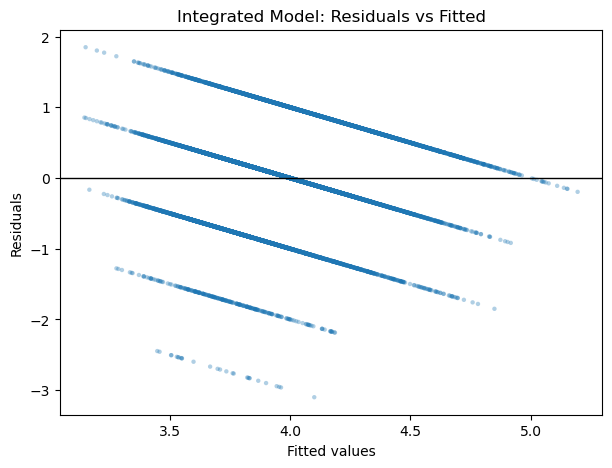

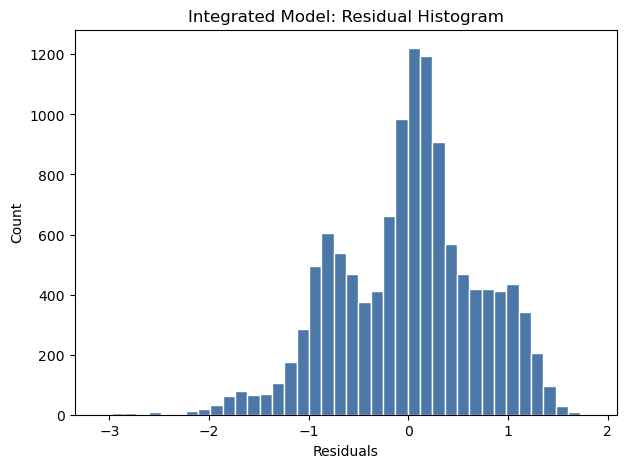

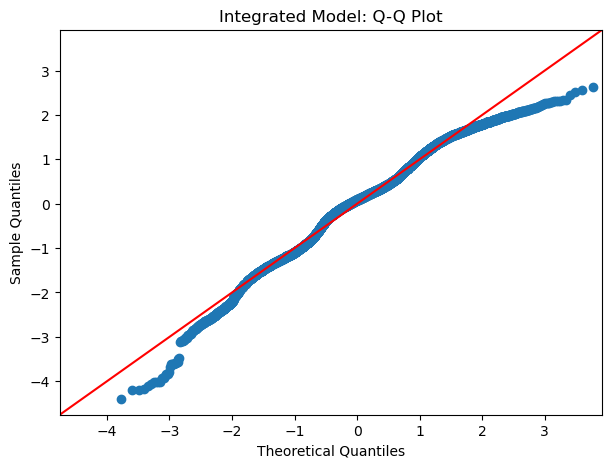

In [8]:
def save_or_show_fig(filename):
    if SAVE_OUTPUTS:
        plt.savefig(FIGURE_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

integrated_model = MODELS["Integrated Model"]
fitted = integrated_model.fittedvalues
resid = integrated_model.resid

plt.figure(figsize=(7, 5))
plt.scatter(fitted, resid, s=10, alpha=0.35, edgecolors="none")
plt.axhline(0, color="black", linewidth=1)
plt.title("Integrated Model: Residuals vs Fitted")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
save_or_show_fig("residuals_vs_fitted_integrated.png")

plt.figure(figsize=(7, 5))
plt.hist(resid, bins=40, color="#4C78A8", edgecolor="white")
plt.title("Integrated Model: Residual Histogram")
plt.xlabel("Residuals")
plt.ylabel("Count")
save_or_show_fig("residual_histogram_integrated.png")

fig = sm.qqplot(resid, line="45", fit=True)
fig.set_size_inches(7, 5)
plt.title("Integrated Model: Q-Q Plot")
save_or_show_fig("qqplot_integrated.png")

## 8. 진단 요약표

In [9]:
bp_any = (heteroskedasticity_tests["Breusch-Pagan p-value"] < 0.05).any()
white_any = (heteroskedasticity_tests["White p-value"] < 0.05).any()
hetero_summary = "BP 또는 White test에서 p < .05인 모형이 확인됨" if (bp_any or white_any) else "BP/White test에서 뚜렷한 이분산 증거가 확인되지 않음"

max_core_vif = float(vif_core_variables["VIF"].max()) if not vif_core_variables.empty else np.nan
max_core_vif_row = vif_core_variables.loc[vif_core_variables["VIF"].idxmax()] if not vif_core_variables.empty else None
vif_summary = f"핵심 변수 최대 VIF={max_core_vif:.2f} ({max_core_vif_row['모형']} / {max_core_vif_row['변수']})" if max_core_vif_row is not None else "핵심 변수 VIF 계산 불가"

max_centered_vif = float(vif_centered_comparison["중심화 후 VIF"].max()) if not vif_centered_comparison.empty else np.nan
max_original_integrated_vif = float(vif_centered_comparison["원모형 VIF"].max()) if not vif_centered_comparison.empty else np.nan
centered_summary = f"Integrated 핵심 변수 최대 VIF는 원모형 {max_original_integrated_vif:.2f}, 중심화 후 {max_centered_vif:.2f}"

if pd.isna(max_core_vif):
    vif_judge = "확인 필요"
elif max_core_vif < 5:
    vif_judge = "핵심 변수 기준 낮음"
elif max_core_vif < 10:
    vif_judge = "일부 변수 주의 필요"
else:
    vif_judge = "높은 공선성 주의 필요"

if pd.isna(max_centered_vif):
    centered_judge = "확인 필요"
elif max_centered_vif < max_original_integrated_vif:
    centered_judge = "중심화 후 공선성 완화"
else:
    centered_judge = "중심화 후에도 추가 확인 필요"

diagnostics_summary = pd.DataFrame([
    {
        "진단 항목": "이분산",
        "대상 모형": "H1, H2 Headline, H3, Integrated",
        "결과 요약": hetero_summary,
        "판단": "이분산 가능성 고려" if (bp_any or white_any) else "뚜렷하지 않음",
        "보고서 반영 방식": "모든 주모형에 HC3 robust SE 적용",
    },
    {
        "진단 항목": "다중공선성",
        "대상 모형": "핵심 변수 VIF",
        "결과 요약": vif_summary,
        "판단": vif_judge,
        "보고서 반영 방식": "핵심 변수 중심 VIF 표 제시",
    },
    {
        "진단 항목": "상호작용항 공선성",
        "대상 모형": "Integrated Model",
        "결과 요약": centered_summary,
        "판단": centered_judge,
        "보고서 반영 방식": "평균중심화 VIF를 보조 진단으로 제시",
    },
    {
        "진단 항목": "순서형 DV 적합성",
        "대상 모형": "effect_proc_improve",
        "결과 요약": "DV가 1~5점 순서형 변수임",
        "판단": "OLS 해석 보조 확인 필요",
        "보고서 반영 방식": "Ordered Logit 보조모형으로 강건성 확인",
    },
    {
        "진단 항목": "평행추세",
        "대상 모형": "단면 회귀모형",
        "결과 요약": "2024년 단일 연도 기업 단위 단면자료",
        "판단": "해당 없음",
        "보고서 반영 방식": "DID/패널모형이 아니므로 핵심 진단 대상 아님",
    },
    {
        "진단 항목": "과분산",
        "대상 모형": "OLS 주모형",
        "결과 요약": "종속변수가 count형 변수가 아님",
        "판단": "해당 없음",
        "보고서 반영 방식": "Poisson/NB 과분산 진단은 주모형 대상 아님",
    },
])

display(diagnostics_summary)

,진단 항목,대상 모형,결과 요약,판단,보고서 반영 방식
0,이분산,"H1, H2 Headline, H3, Integrated",BP 또는 White test에서 p < .05인 모형이 확인됨,이분산 가능성 고려,모든 주모형에 HC3 robust SE 적용
1,다중공선성,핵심 변수 VIF,핵심 변수 최대 VIF=5.86 (Integrated Model / ai_use_s...,일부 변수 주의 필요,핵심 변수 중심 VIF 표 제시
2,상호작용항 공선성,Integrated Model,"Integrated 핵심 변수 최대 VIF는 원모형 5.86, 중심화 후 3.12",중심화 후 공선성 완화,평균중심화 VIF를 보조 진단으로 제시
3,순서형 DV 적합성,effect_proc_improve,DV가 1~5점 순서형 변수임,OLS 해석 보조 확인 필요,Ordered Logit 보조모형으로 강건성 확인
4,평행추세,단면 회귀모형,2024년 단일 연도 기업 단위 단면자료,해당 없음,DID/패널모형이 아니므로 핵심 진단 대상 아님
5,과분산,OLS 주모형,종속변수가 count형 변수가 아님,해당 없음,Poisson/NB 과분산 진단은 주모형 대상 아님


## 9. 보고서용 해석 문장 초안

In [10]:
min_bp_p = heteroskedasticity_tests["Breusch-Pagan p-value"].min()
min_white_p = heteroskedasticity_tests["White p-value"].min()
max_vif_text = f"{max_core_vif:.2f}" if pd.notna(max_core_vif) else "확인 필요"
max_centered_text = f"{max_centered_vif:.2f}" if pd.notna(max_centered_vif) else "확인 필요"
max_original_text = f"{max_original_integrated_vif:.2f}" if pd.notna(max_original_integrated_vif) else "확인 필요"

interpretation_notes = f"""
모형 진단 결과, Breusch-Pagan 검정의 최소 p-value는 {min_bp_p:.4f}, White 검정의 최소 p-value는 {min_white_p:.4f}로 확인되었다. 일부 모형에서 이분산 가능성을 배제하기 어려우므로, 본 연구의 OLS 주모형은 모두 HC3 robust standard error를 적용하여 추정하였다.

다중공선성 진단에서는 보고서용 핵심 변수 기준 최대 VIF가 {max_vif_text}로 나타났다. VIF 기준상 심각한 수준인지 여부는 변수별 표를 함께 확인할 필요가 있으며, 특히 상호작용항이 포함된 모형에서는 공선성 증가 가능성을 고려하였다.

Integrated Model에 대해 평균중심화 보조 진단을 수행한 결과, 핵심 변수 최대 VIF는 원모형 {max_original_text}에서 중심화 후 {max_centered_text}로 확인되었다. 평균중심화는 상호작용항 해석과 공선성 진단을 돕기 위한 보조 절차이며, 주모형의 결과 해석은 원래 모형을 기준으로 유지하였다.

종속변수 effect_proc_improve는 1~5점 순서형 변수이므로, OLS 결과의 보완을 위해 Ordered Logit 대안모형을 별도로 검토하였다. 한편 본 연구는 2024년 단일 연도 기업 단위 단면자료를 사용하므로 평행추세 검정은 해당되지 않으며, 종속변수가 count형 변수가 아니므로 과분산 진단 역시 주모형의 핵심 진단 대상은 아니다.
""".strip()

print(interpretation_notes)

모형 진단 결과, Breusch-Pagan 검정의 최소 p-value는 0.0000, White 검정의 최소 p-value는 0.0000로 확인되었다. 일부 모형에서 이분산 가능성을 배제하기 어려우므로, 본 연구의 OLS 주모형은 모두 HC3 robust standard error를 적용하여 추정하였다.

다중공선성 진단에서는 보고서용 핵심 변수 기준 최대 VIF가 5.86로 나타났다. VIF 기준상 심각한 수준인지 여부는 변수별 표를 함께 확인할 필요가 있으며, 특히 상호작용항이 포함된 모형에서는 공선성 증가 가능성을 고려하였다.

Integrated Model에 대해 평균중심화 보조 진단을 수행한 결과, 핵심 변수 최대 VIF는 원모형 5.86에서 중심화 후 3.12로 확인되었다. 평균중심화는 상호작용항 해석과 공선성 진단을 돕기 위한 보조 절차이며, 주모형의 결과 해석은 원래 모형을 기준으로 유지하였다.

종속변수 effect_proc_improve는 1~5점 순서형 변수이므로, OLS 결과의 보완을 위해 Ordered Logit 대안모형을 별도로 검토하였다. 한편 본 연구는 2024년 단일 연도 기업 단위 단면자료를 사용하므로 평행추세 검정은 해당되지 않으며, 종속변수가 count형 변수가 아니므로 과분산 진단 역시 주모형의 핵심 진단 대상은 아니다.


## 10. 저장

In [11]:
if SAVE_OUTPUTS:
    heteroskedasticity_tests.to_csv(TABLE_DIR / "heteroskedasticity_tests.csv", index=False, encoding="utf-8-sig")
    heteroskedasticity_tests.to_excel(TABLE_DIR / "heteroskedasticity_tests.xlsx", index=False)

    vif_core_variables.to_csv(TABLE_DIR / "vif_core_variables.csv", index=False, encoding="utf-8-sig")
    vif_core_variables.to_excel(TABLE_DIR / "vif_core_variables.xlsx", index=False)

    vif_centered_comparison.to_csv(TABLE_DIR / "vif_centered_comparison.csv", index=False, encoding="utf-8-sig")
    vif_centered_comparison.to_excel(TABLE_DIR / "vif_centered_comparison.xlsx", index=False)

    diagnostics_summary.to_csv(TABLE_DIR / "diagnostics_summary.csv", index=False, encoding="utf-8-sig")
    diagnostics_summary.to_excel(TABLE_DIR / "diagnostics_summary.xlsx", index=False)

    model_fit_table.to_csv(TABLE_DIR / "model_fit_stats.csv", index=False, encoding="utf-8-sig")
    model_fit_table.to_excel(TABLE_DIR / "model_fit_stats.xlsx", index=False)

    (OUTPUT_DIR / "diagnostics_interpretation_notes.txt").write_text(interpretation_notes, encoding="utf-8")

    with pd.ExcelWriter(OUTPUT_DIR / "model_diagnostics_summary.xlsx") as writer:
        variable_check.to_excel(writer, sheet_name="variable_check", index=False)
        model_fit_table.to_excel(writer, sheet_name="model_fit_stats", index=False)
        heteroskedasticity_tests.to_excel(writer, sheet_name="heteroskedasticity", index=False)
        vif_core_variables.to_excel(writer, sheet_name="vif_core", index=False)
        vif_centered_comparison.to_excel(writer, sheet_name="vif_centered", index=False)
        diagnostics_summary.to_excel(writer, sheet_name="diagnostics_summary", index=False)

    print("저장 완료:", OUTPUT_DIR)
else:
    print("SAVE_OUTPUTS=False: 파일 저장 없이 노트북 내 출력만 수행했습니다.")

저장 완료: /Users/yenarue/Downloads/ITM.89912(A)/연구 데이터/outputs/10_model_diagnostics


## 11. 실행 요약

In [12]:
print("진단 모형 수:", len(MODELS))
print("이분산 진단 행 수:", len(heteroskedasticity_tests))
print("핵심 VIF 행 수:", len(vif_core_variables))
print("중심화 VIF 비교 행 수:", len(vif_centered_comparison))
print("SAVE_OUTPUTS:", SAVE_OUTPUTS)

진단 모형 수: 4
이분산 진단 행 수: 4
핵심 VIF 행 수: 18
중심화 VIF 비교 행 수: 7
SAVE_OUTPUTS: True
